### Команда для запуска эксперимента

__ВАЖНО:__ надо менять папку с конфигом эксперимента и output_dir

In [1]:
# accelerate launch ./mult_3_dreambooth/train_dreambooth_lora_sdxl.py   --pretrained_model_name_or_path="stabilityai/stable-diffusion-xl-base-1.0"   --pretrained_vae_model_name_or_path="madebyollin/sdxl-vae-fp16-fix"   --instance_data_dir="./dataset/few_shot/instance_images"   --class_data_dir="./dataset/few_shot/class_images"   --instance_prompt="a photo of a sks dog"   --class_prompt="a photo of a dog"   --output_dir="./mult_3_dreambooth"   --resolution=1024   --train_batch_size=1   --gradient_accumulation_steps=1   --learning_rate=1e-4   --lr_scheduler="constant"   --lr_warmup_steps=0   --max_train_steps=500   --checkpointing_steps=100   --mixed_precision="fp16"   --enable_xformers_memory_efficient_attention   --gradient_checkpointing   --with_prior_preservation   --prior_loss_weight=1.0   --seed=42

In [2]:
# accelerate launch ./base_dynamic/train_dreambooth_lora_sdxl.py   --pretrained_model_name_or_path="stabilityai/stable-diffusion-xl-base-1.0"   --pretrained_vae_model_name_or_path="madebyollin/sdxl-vae-fp16-fix"   --instance_data_dir="./dataset/few_shot/instance_images"   --class_data_dir="./dataset/few_shot/class_images"   --instance_prompt="a photo of a sks dog"   --class_prompt="a photo of a dog"   --output_dir="./base_dynamic"   --resolution=1024   --train_batch_size=1   --gradient_accumulation_steps=1   --learning_rate=1e-4   --lr_scheduler="constant"   --lr_warmup_steps=0   --max_train_steps=1000   --checkpointing_steps=100   --mixed_precision="fp16"   --enable_xformers_memory_efficient_attention   --gradient_checkpointing   --with_prior_preservation   --prior_loss_weight=1.0   --seed=42

In [3]:
# accelerate launch ./mult_1_right_dynamic_one_shot/train_dreambooth_lora_sdxl.py   --pretrained_model_name_or_path="stabilityai/stable-diffusion-xl-base-1.0"   --pretrained_vae_model_name_or_path="madebyollin/sdxl-vae-fp16-fix"   --instance_data_dir="./dataset/few_shot/instance_images_one"   --class_data_dir="./dataset/few_shot/class_images"   --instance_prompt="a photo of a sks dog"   --class_prompt="a photo of a dog"   --output_dir="./mult_1_right_dynamic_one_shot"   --resolution=1024   --train_batch_size=1   --gradient_accumulation_steps=1   --learning_rate=1e-4   --lr_scheduler="constant"   --lr_warmup_steps=0   --max_train_steps=1000   --checkpointing_steps=100   --mixed_precision="fp16"   --enable_xformers_memory_efficient_attention   --gradient_checkpointing   --with_prior_preservation   --prior_loss_weight=1.0   --seed=42

### Библиотеки

In [4]:
import torch

import seaborn as sns
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'retina'
sns.set_style("darkgrid")

### Визуализация распределений

<Axes: ylabel='Count'>

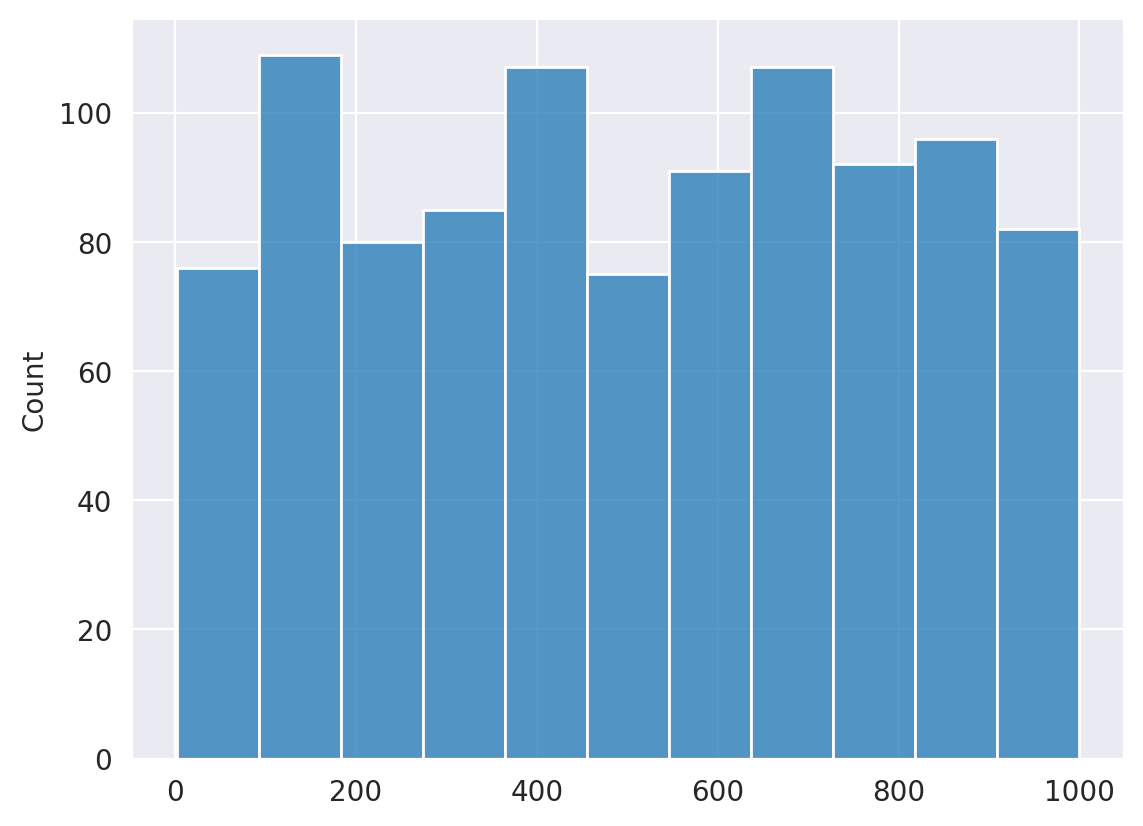

In [5]:
idx =  torch.randint(0, 1000, (1000, ))
sns.histplot(idx)

In [6]:
def sample_timesteps_power(T, bsz, alpha=3.0, device="cpu"):
    """
    Sample timesteps with power bias toward later (low-noise) steps.
    T: total number of timesteps
    bsz: batch size
    alpha: bias strength (bigger => more samples near t=0)
    """
    t = torch.arange(T, dtype=torch.float32, device=device)
    tau = t / (T - 1)                      # normalize 0..1
    probs = (1.0 - tau) ** alpha   # bias distribution
    probs = probs / probs.sum()            # normalize to sum=1
    idx = torch.multinomial(probs, bsz, replacement=True)
    return idx, probs[idx]

<Axes: ylabel='Count'>

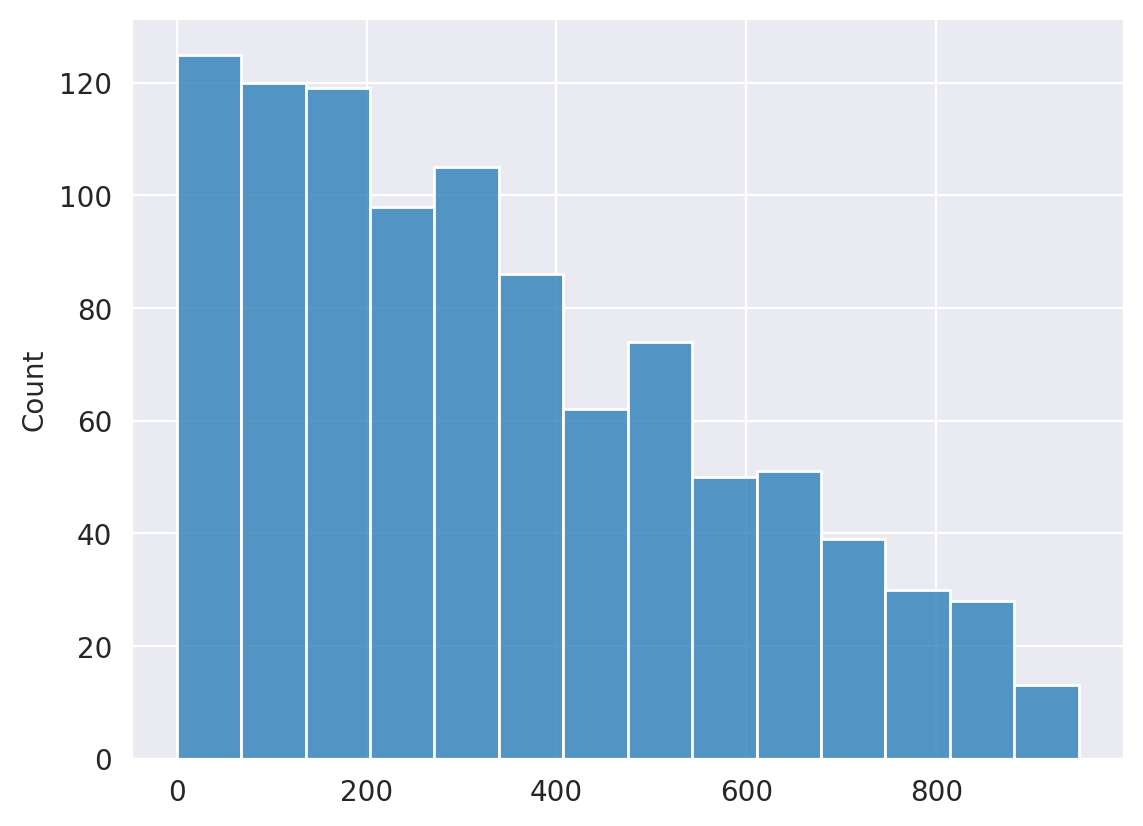

In [7]:
idx, probs = sample_timesteps_power(1000, 1000, alpha=1, device="cpu")
sns.histplot(idx)

In [8]:
def sample_timesteps_power_right_tail(T, bsz, alpha=3.0, device="cpu"):
    """
    Sample timesteps with power bias toward earlier (high-noise) steps.
    T: total number of timesteps
    bsz: batch size
    alpha: bias strength (bigger => more samples near t=T-1)
    """
    t = torch.arange(T, dtype=torch.float32, device=device)
    tau = t / (T - 1)                     # normalize 0..1
    probs = tau ** alpha                  # bias toward large t
    probs = probs / probs.sum()           # normalize
    idx = torch.multinomial(probs, bsz, replacement=True)
    return idx, probs[idx]

<Axes: ylabel='Count'>

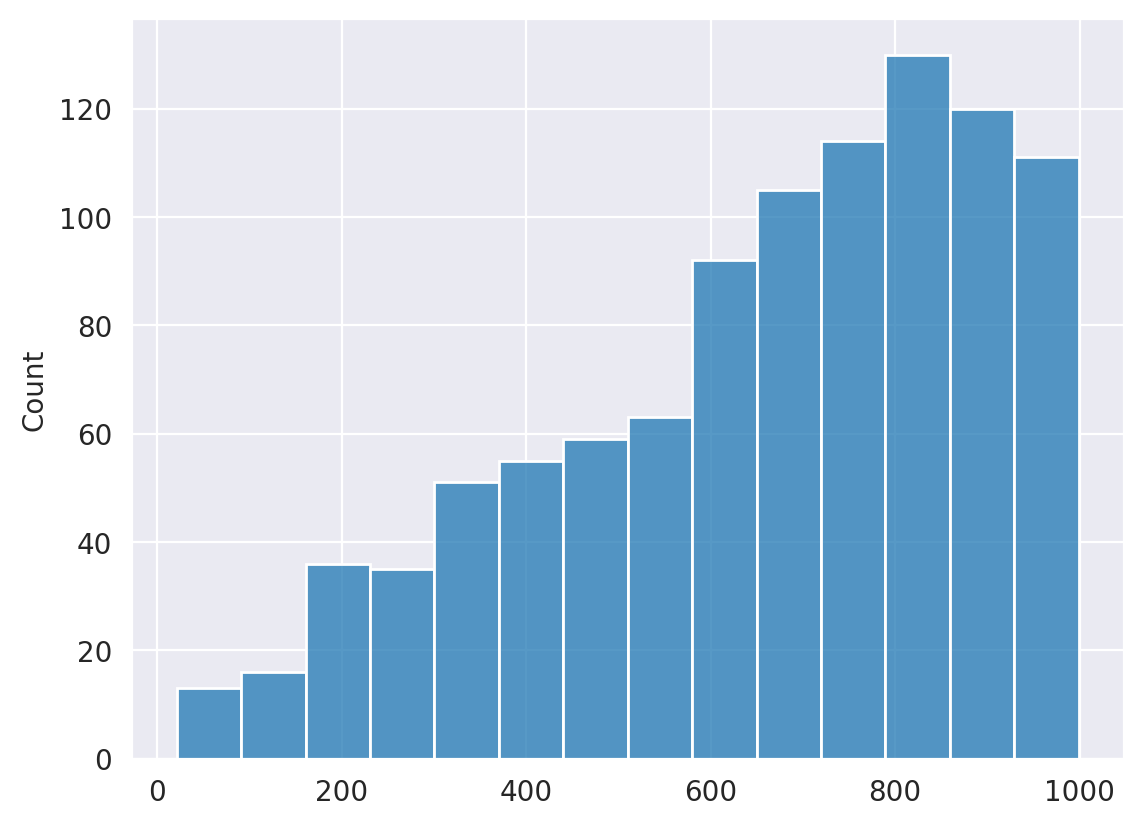

In [9]:
idx, probs = sample_timesteps_power_right_tail(1000, 1000, alpha=1, device="cpu")
sns.histplot(idx)

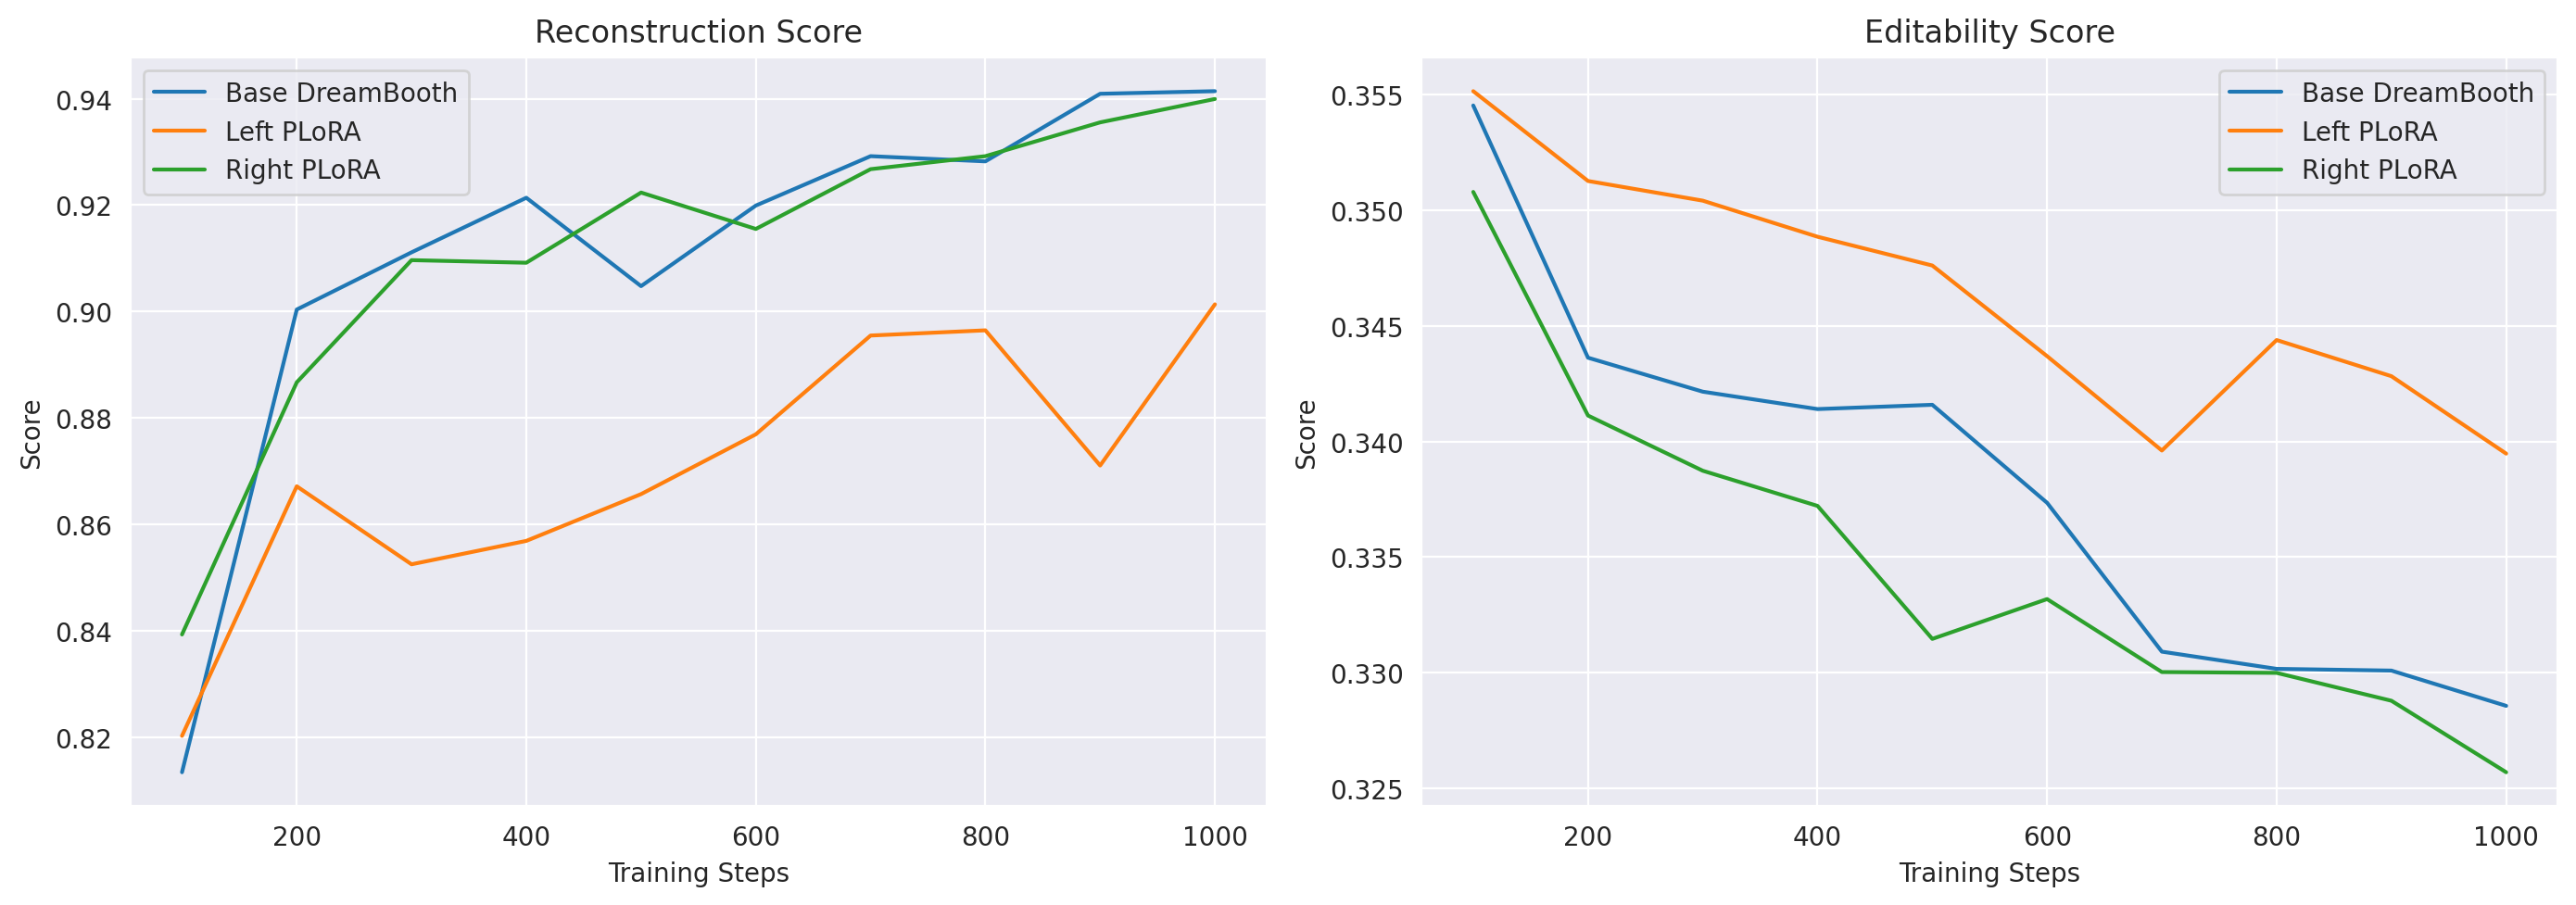

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'
sns.set_style("darkgrid")

# ---- DATA ----
# few_shot
base_rec_few = {100: 0.8134765625,
 200: 0.900390625,
 300: 0.9111328125,
 400: 0.92138671875,
 500: 0.90478515625,
 600: 0.919921875,
 700: 0.92919921875,
 800: 0.92822265625,
 900: 0.94091796875,
 1000: 0.94140625}

base_edit_few = {100: 0.35452368951612906,
 200: 0.34362005418346775,
 300: 0.3421512726814516,
 400: 0.34139916204637094,
 500: 0.34158423639112906,
 600: 0.3373472152217742,
 700: 0.3309129284274194,
 800: 0.33016869329637094,
 900: 0.3300938760080645,
 1000: 0.32856996597782256}

left_rec_few = {100: 0.8203125,
 200: 0.8671875,
 300: 0.8525390625,
 400: 0.85693359375,
 500: 0.86572265625,
 600: 0.876953125,
 700: 0.8955078125,
 800: 0.896484375,
 900: 0.87109375,
 1000: 0.9013671875}

left_edit_few = {100: 0.3551419165826613,
 200: 0.35125929309475806,
 300: 0.3504087386592742,
 400: 0.3488493888608871,
 500: 0.3476050592237903,
 600: 0.34368699596774194,
 700: 0.33960748487903225,
 800: 0.34438397807459675,
 900: 0.34282069052419356,
 1000: 0.3394736013104839}

right_rec_few = {100: 0.83935546875,
 200: 0.88671875,
 300: 0.90966796875,
 400: 0.9091796875,
 500: 0.92236328125,
 600: 0.91552734375,
 700: 0.9267578125,
 800: 0.92919921875,
 900: 0.935546875,
 1000: 0.93994140625}

right_edit_few = {100: 0.35078676285282256,
 200: 0.3411195816532258,
 300: 0.3387333039314516,
 400: 0.3372133316532258,
 500: 0.33146421370967744,
 600: 0.3331850113407258,
 700: 0.33003087197580644,
 800: 0.3299954322076613,
 900: 0.3287904800907258,
 1000: 0.3256993447580645}

# ---- PLOTTING ----
steps = list(base_rec_few.keys())

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# --- Reconstruction subplot ---
axs[0].plot(steps, base_rec_few.values(), label="Base DreamBooth")
axs[0].plot(steps, left_rec_few.values(), label="Left PLoRA")
axs[0].plot(steps, right_rec_few.values(), label="Right PLoRA")

axs[0].set_title("Reconstruction Score")
axs[0].set_xlabel("Training Steps")
axs[0].set_ylabel("Score")
axs[0].legend()
axs[0].grid(True)

# --- Editability subplot ---
axs[1].plot(steps, base_edit_few.values(), label="Base DreamBooth")
axs[1].plot(steps, left_edit_few.values(), label="Left PLoRA")
axs[1].plot(steps, right_edit_few.values(), label="Right PLoRA")

axs[1].set_title("Editability Score")
axs[1].set_xlabel("Training Steps")
axs[1].set_ylabel("Score")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

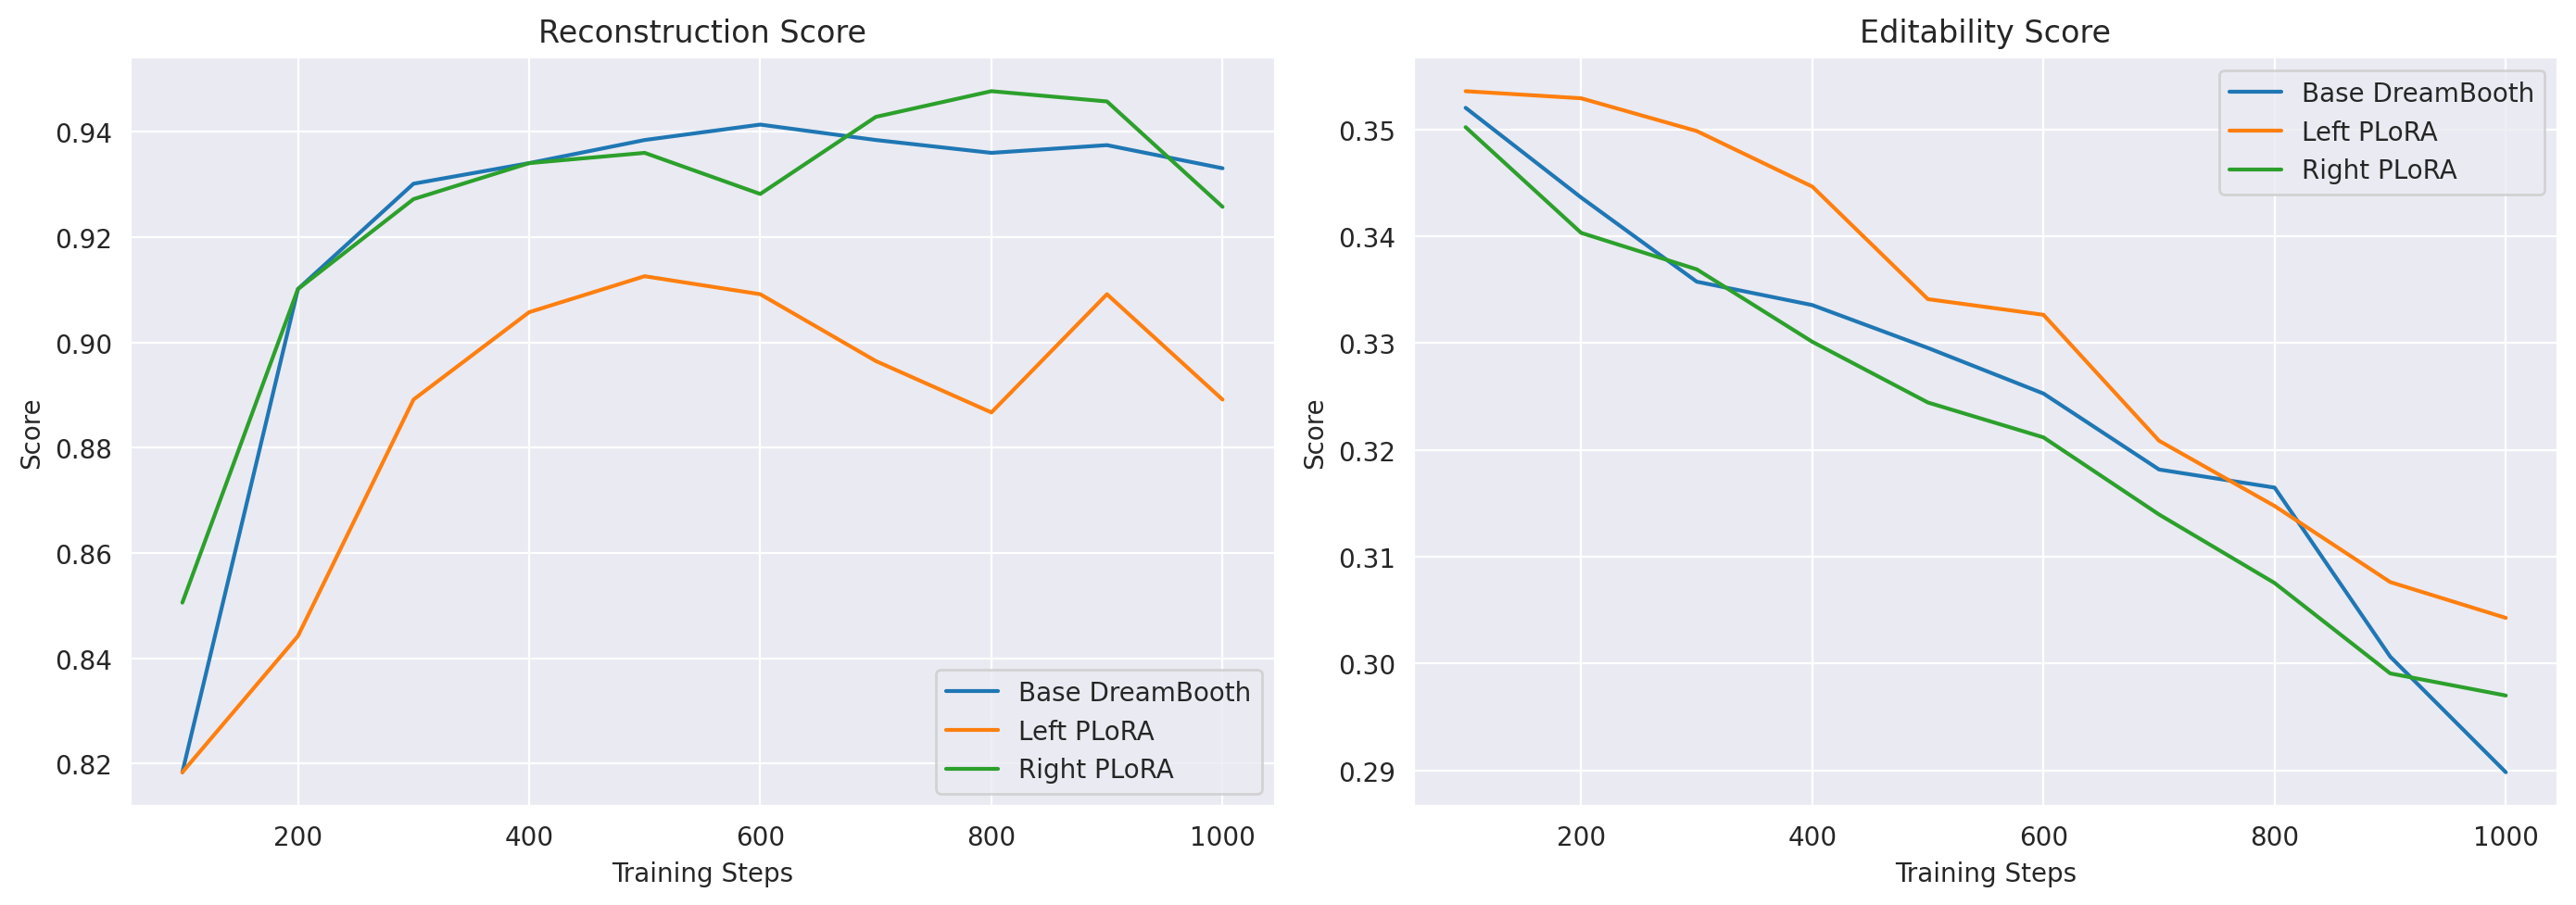

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'
sns.set_style("darkgrid")

# ---- DATA ----
# one shot

base_rec_one = {100: 0.818359375,
 200: 0.91015625,
 300: 0.93017578125,
 400: 0.93408203125,
 500: 0.9384765625,
 600: 0.94140625,
 700: 0.9384765625,
 800: 0.93603515625,
 900: 0.9375,
 1000: 0.93310546875}

base_edit_one = {100: 0.35202715473790325,
 200: 0.3436239919354839,
 300: 0.3357484879032258,
 400: 0.33355909778225806,
 500: 0.32954652847782256,
 600: 0.3252780052923387,
 700: 0.3181664251512097,
 800: 0.3164712229082661,
 900: 0.3006493353074597,
 1000: 0.2898283927671371}

left_rec_one = {100: 0.818359375,
 200: 0.84423828125,
 300: 0.88916015625,
 400: 0.90576171875,
 500: 0.91259765625,
 600: 0.9091796875,
 700: 0.896484375,
 800: 0.88671875,
 900: 0.9091796875,
 1000: 0.88916015625}

left_edit_one = {100: 0.3535825667842742,
 200: 0.3529170866935484,
 300: 0.3498495778729839,
 400: 0.34464780745967744,
 500: 0.33411432081653225,
 600: 0.33264947706653225,
 700: 0.3208578786542339,
 800: 0.3147484564012097,
 900: 0.3076290007560484,
 1000: 0.3042760049143145}

right_rec_one = {100: 0.8505859375,
 200: 0.91015625,
 300: 0.92724609375,
 400: 0.93408203125,
 500: 0.93603515625,
 600: 0.92822265625,
 700: 0.94287109375,
 800: 0.94775390625,
 900: 0.94580078125,
 1000: 0.92578125}

right_edit_one = {100: 0.3502157888104839,
 200: 0.3403162802419355,
 300: 0.33690618699596775,
 400: 0.33012144027217744,
 500: 0.32443926411290325,
 600: 0.32117486769153225,
 700: 0.3139549993699597,
 800: 0.30753843245967744,
 900: 0.29908014112903225,
 1000: 0.2970088835685484}

# ---- PLOTTING ----
steps = list(base_rec_one.keys())

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# --- Reconstruction subplot ---
axs[0].plot(steps, base_rec_one.values(), label="Base DreamBooth")
axs[0].plot(steps, left_rec_one.values(), label="Left PLoRA")
axs[0].plot(steps, right_rec_one.values(), label="Right PLoRA")

axs[0].set_title("Reconstruction Score")
axs[0].set_xlabel("Training Steps")
axs[0].set_ylabel("Score")
axs[0].legend()
axs[0].grid(True)

# --- Editability subplot ---
axs[1].plot(steps, base_edit_one.values(), label="Base DreamBooth")
axs[1].plot(steps, left_edit_one.values(), label="Left PLoRA")
axs[1].plot(steps, right_edit_one.values(), label="Right PLoRA")

axs[1].set_title("Editability Score")
axs[1].set_xlabel("Training Steps")
axs[1].set_ylabel("Score")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

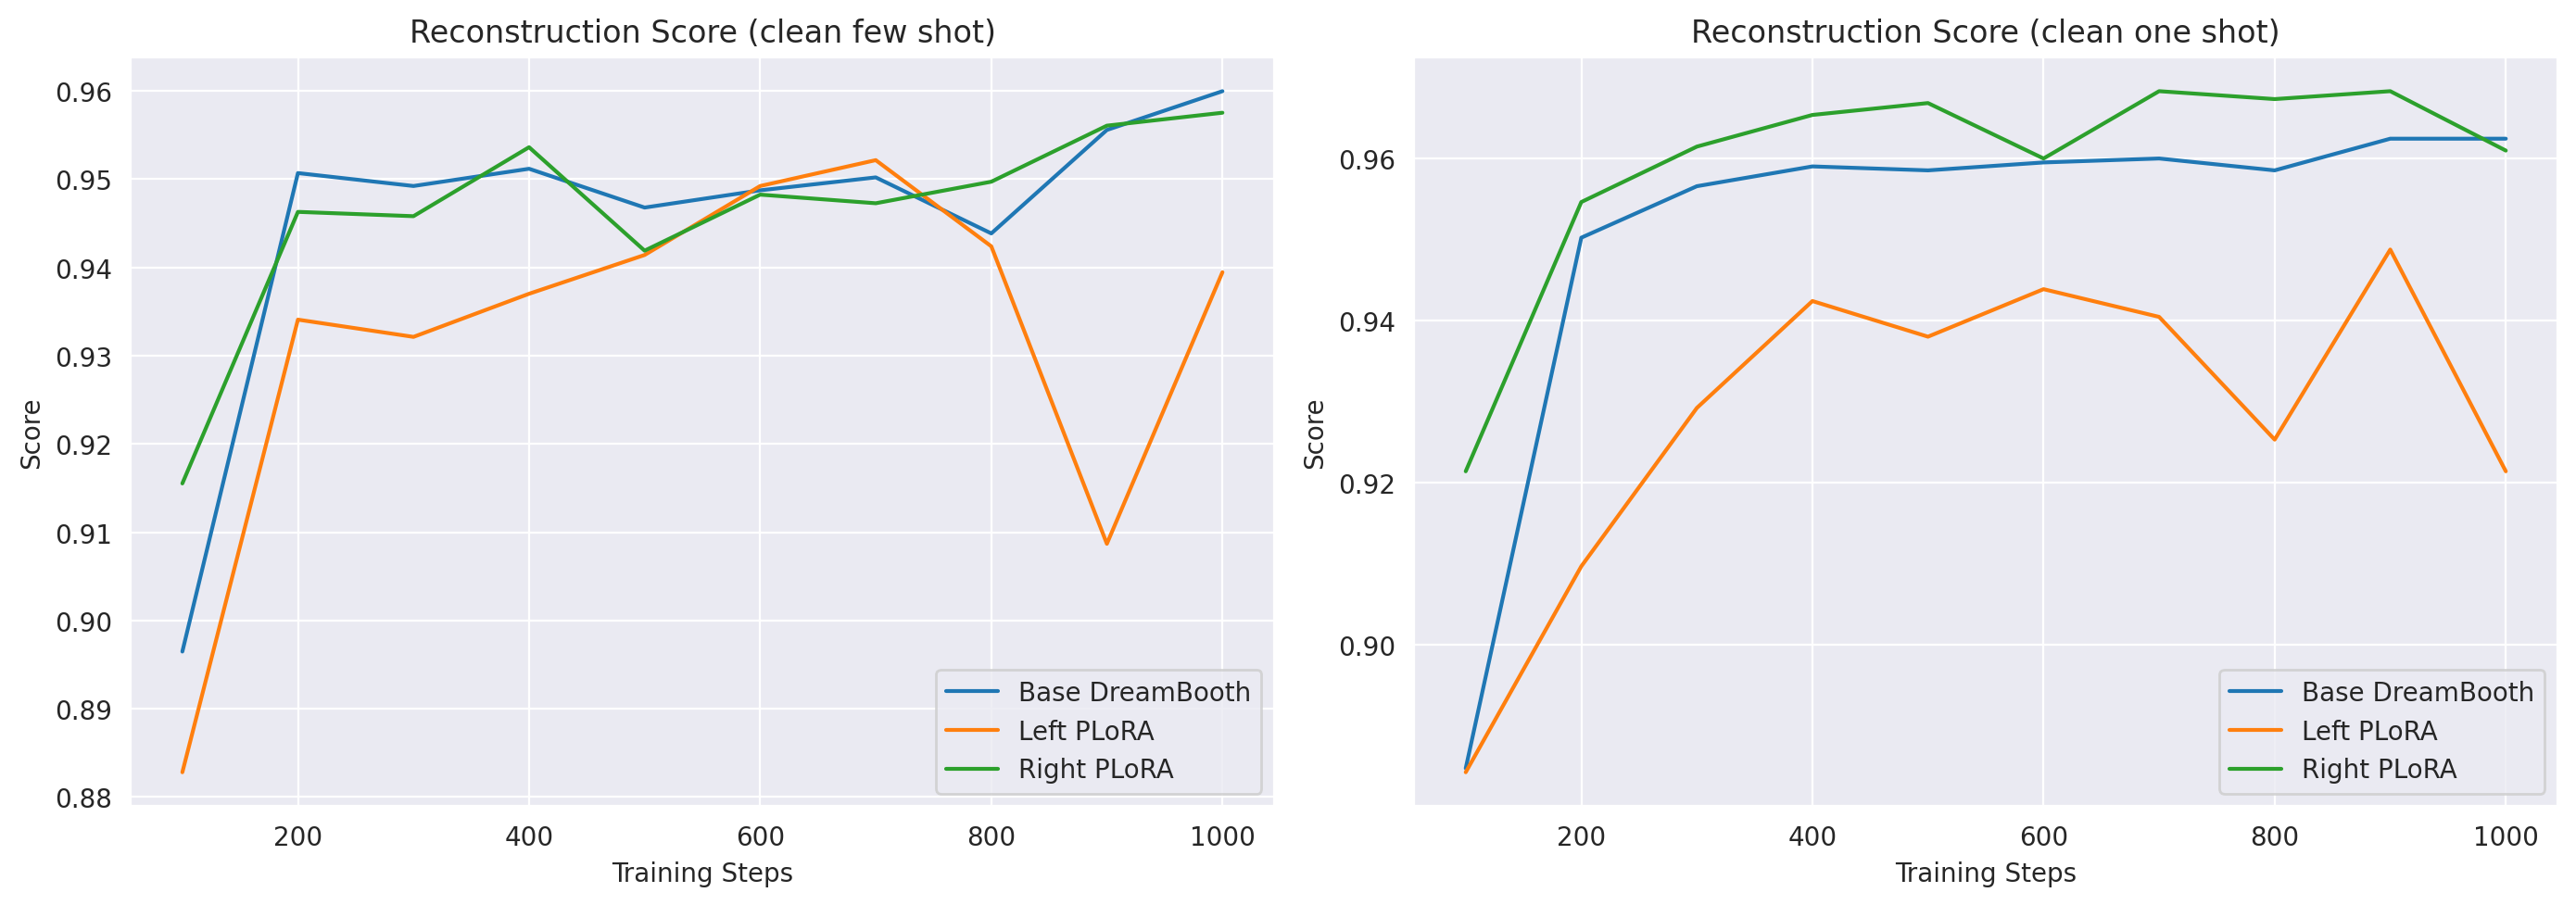

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'
sns.set_style("darkgrid")

# ---- DATA ----
# clean_images

base_rec_few_clean = {100: 0.896484375,
 200: 0.95068359375,
 300: 0.94921875,
 400: 0.951171875,
 500: 0.94677734375,
 600: 0.94873046875,
 700: 0.9501953125,
 800: 0.94384765625,
 900: 0.95556640625,
 1000: 0.9599609375}

base_rec_one_clean = {100: 0.884765625,
 200: 0.9501953125,
 300: 0.95654296875,
 400: 0.958984375,
 500: 0.95849609375,
 600: 0.95947265625,
 700: 0.9599609375,
 800: 0.95849609375,
 900: 0.96240234375,
 1000: 0.96240234375}

left_rec_few_clean={100: 0.8828125,
 200: 0.93408203125,
 300: 0.93212890625,
 400: 0.93701171875,
 500: 0.94140625,
 600: 0.94921875,
 700: 0.9521484375,
 800: 0.9423828125,
 900: 0.90869140625,
 1000: 0.939453125}

left_rec_one_clean = {100: 0.88427734375,
 200: 0.90966796875,
 300: 0.92919921875,
 400: 0.9423828125,
 500: 0.93798828125,
 600: 0.94384765625,
 700: 0.9404296875,
 800: 0.92529296875,
 900: 0.94873046875,
 1000: 0.92138671875}

right_rec_few_clean = {100: 0.91552734375,
 200: 0.9462890625,
 300: 0.94580078125,
 400: 0.95361328125,
 500: 0.94189453125,
 600: 0.9482421875,
 700: 0.947265625,
 800: 0.94970703125,
 900: 0.9560546875,
 1000: 0.95751953125}

right_rec_one_clean = {100: 0.92138671875,
 200: 0.95458984375,
 300: 0.96142578125,
 400: 0.96533203125,
 500: 0.966796875,
 600: 0.9599609375,
 700: 0.96826171875,
 800: 0.96728515625,
 900: 0.96826171875,
 1000: 0.9609375}

 # ---- PLOTTING ----
steps = list(base_rec_few_clean.keys())

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# --- Reconstruction subplot ---
axs[0].plot(steps, base_rec_few_clean.values(), label="Base DreamBooth")
axs[0].plot(steps, left_rec_few_clean.values(), label="Left PLoRA")
axs[0].plot(steps, right_rec_few_clean.values(), label="Right PLoRA")

axs[0].set_title("Reconstruction Score (clean few shot)")
axs[0].set_xlabel("Training Steps")
axs[0].set_ylabel("Score")
axs[0].legend()
axs[0].grid(True)

# --- Editability subplot ---
axs[1].plot(steps, base_rec_one_clean.values(), label="Base DreamBooth")
axs[1].plot(steps, left_rec_one_clean.values(), label="Left PLoRA")
axs[1].plot(steps, right_rec_one_clean.values(), label="Right PLoRA")

axs[1].set_title("Reconstruction Score (clean one shot)")
axs[1].set_xlabel("Training Steps")
axs[1].set_ylabel("Score")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
data = [
     base_rec_few,
     base_edit_few,
     left_rec_few,
     left_edit_few,
     right_rec_few,
     right_edit_few,
     base_rec_one,
     base_edit_one,
     left_rec_one,
     left_edit_one,
     right_rec_one,
     right_edit_one,
     base_rec_few_clean,
     base_rec_one_clean,
     left_rec_few_clean,
     left_rec_one_clean,
     right_rec_few_clean,
     right_rec_one_clean
]

col_names = [
     "base_rec_few",
     "base_edit_few",
     "left_rec_few",
     "left_edit_few",
     "right_rec_few",
     "right_edit_few",
     "base_rec_one",
     "base_edit_one",
     "left_rec_one",
     "left_edit_one",
     "right_rec_one",
     "right_edit_one",
     "base_rec_few_clean",
     "base_rec_one_clean",
     "left_rec_few_clean",
     "left_rec_one_clean",
     "right_rec_few_clean",
     "right_rec_one_clean"
]

notes = pd.DataFrame(data).T
notes.columns = col_names

In [19]:
notes

,base_rec_few,base_edit_few,left_rec_few,left_edit_few,right_rec_few,right_edit_few,base_rec_one,base_edit_one,left_rec_one,left_edit_one,right_rec_one,right_edit_one,base_rec_few_clean,base_rec_one_clean,left_rec_few_clean,left_rec_one_clean,right_rec_few_clean,right_rec_one_clean
100,0.813477,0.354524,0.820312,0.355142,0.839355,0.350787,0.818359,0.352027,0.818359,0.353583,0.850586,0.350216,0.896484,0.884766,0.882812,0.884277,0.915527,0.921387
200,0.900391,0.343620,0.867188,0.351259,0.886719,0.341120,0.910156,0.343624,0.844238,0.352917,0.910156,0.340316,0.950684,0.950195,0.934082,0.909668,0.946289,0.954590
300,0.911133,0.342151,0.852539,0.350409,0.909668,0.338733,0.930176,0.335748,0.889160,0.349850,0.927246,0.336906,0.949219,0.956543,0.932129,0.929199,0.945801,0.961426
400,0.921387,0.341399,0.856934,0.348849,0.909180,0.337213,0.934082,0.333559,0.905762,0.344648,0.934082,0.330121,0.951172,0.958984,0.937012,0.942383,0.953613,0.965332
500,0.904785,0.341584,0.865723,0.347605,0.922363,0.331464,0.938477,0.329547,0.912598,0.334114,0.936035,0.324439,0.946777,0.958496,0.941406,0.937988,0.941895,0.966797
600,0.919922,0.337347,0.876953,0.343687,0.915527,0.333185,0.941406,0.325278,0.909180,0.332649,0.928223,0.321175,0.948730,0.959473,0.949219,0.943848,0.948242,0.959961
700,0.929199,0.330913,0.895508,0.339607,0.926758,0.330031,0.938477,0.318166,0.896484,0.320858,0.942871,0.313955,0.950195,0.959961,0.952148,0.940430,0.947266,0.968262
800,0.928223,0.330169,0.896484,0.344384,0.929199,0.329995,0.936035,0.316471,0.886719,0.314748,0.947754,0.307538,0.943848,0.958496,0.942383,0.925293,0.949707,0.967285
900,0.940918,0.330094,0.871094,0.342821,0.935547,0.328790,0.937500,0.300649,0.909180,0.307629,0.945801,0.299080,0.955566,0.962402,0.908691,0.948730,0.956055,0.968262
1000,0.941406,0.328570,0.901367,0.339474,0.939941,0.325699,0.933105,0.289828,0.889160,0.304276,0.925781,0.297009,0.959961,0.962402,0.939453,0.921387,0.957520,0.960938


In [20]:
notes.to_csv('results.csv')

___